# Graph and Minimum Spanning Tree analysis of STM Images

### Running In Google Colab

Click the badge below to open the notebook in Colab.

Run the cell below to get setup to subsequently run the rest of notebook. **Note** you'll see a warning that the Kernel crash. This is Colab restarting

<a href="https://colab.research.google.com/github/GallagherSurfaceLab/summer_26/blob/main/STM_voronoi.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from skimage import util, filters, color, morphology
from skimage.segmentation import watershed
from skimage.measure import label
from skimage.restoration import inpaint_biharmonic

from scipy.stats import norm
from scipy.spatial.distance import pdist
from scipy.interpolate import make_interp_spline

from matplotlib import cm

from stm_voronoi_mst import img_file, gray_process, voronoi_tree, find_nodes, statistics

In [ ]:
# ==================
# FILE NAME
# ==================
f = r"sample_scale_53.png"

# ==================
# GRAYSCALE PROCESS
# ==================
dsize = 11
cutoff = 0.3

# ==================
# WATERSHED
# ==================
smooth = False
sigma = 10
low_th = 0.2
high_th = 0.8

# ==================
# VORONOI
# ==================
k = 24
power = 0.3

C:\Users\Matth\AppData\Local\Temp\ipykernel_9236\3999821747.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  camp = cm.get_cmap('afmhot')


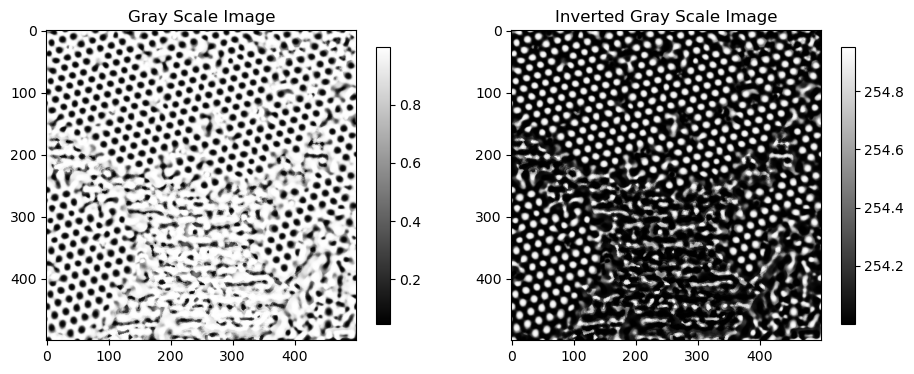

In [ ]:
img = img_file(f)
img.load()

img2d = img.img if img.img.ndim == 2 else img.img.mean(axis = 2)
row_means = img2d.mean(axis = 1)
row_devs = np.abs(img2d - row_means[:, None])

max_dev_per_row = row_devs.max(axis = 1)
threshold = max_dev_per_row.mean() + max_dev_per_row.std()
scarred_rows = max_dev_per_row > threshold

mask = np.zeros(img2d.shape, dtype = bool)
mask [scarred_rows, :] = True

inpainted = np.stack([inpaint_biharmonic(img.img[..., c], mask) for c in range(img.img.shape[2])], axis = -1)
source = (inpainted if hasattr(img, 'img_inpainted') else img.img)
img.img_blurred = filters.gaussian(source, sigma = 3, channel_axis = -1 if source.ndim == 3 else None)
image_gray = np.dot(img.img_blurred[..., :3], [0.2989, 0.5870, 0.1140])
image_norm = (image_gray - image_gray.min()) / (image_gray.max() - image_gray.min())

cmap = cm.get_cmap('afmhot')
colored_image = cmap(image_norm)
img_gr = gray_process(colored_image, dsize = dsize, cutoff = cutoff)
img_pr = 255 - img_gr

fig, ax = plt.subplots(1, 2, figsize = (11, 6))
im0 = ax[0].imshow(img_gr, cmap = 'gray')
ax[0].set_title('Gray Scale Image')
im1 = ax[1].imshow(img_pr, cmap = 'gray')
ax[1].set_title('Inverted Gray Scale Image')

fig.colorbar(im0, ax = ax[0], shrink = 0.6)
fig.colorbar(im1, ax = ax[1], shrink = 0.6)

# Segmentation and Initial Labelling of the Regions

Labeling of the regions of interest are done using the the [watershed segmentation](https://scikit-image.org/docs/stable/auto_examples/applications/plot_coins_segmentation.html) technique. This requires
identifying a low threshold `low_th` which defines background pixels and a high threshold
`high_th` which defines the object we are looking at. These threshold can be determined
from the color bar of the *Inverted Grey Scale Image* about. The high threshold are the
bright regions (>0.8) and the low threshold are the dark regions (<0.2).


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [177.80063773583606..178.76680188877572].


Text(0.5, 1.0, 'Segments Overlayed on Data')

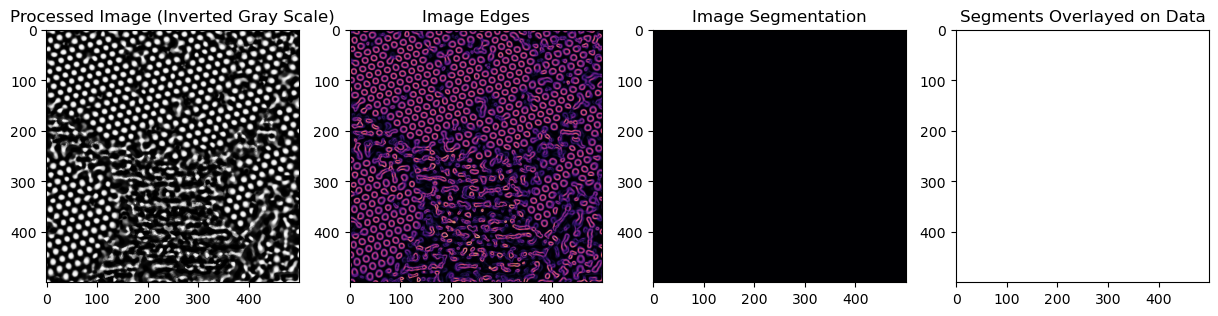

In [ ]:
if smooth == True:
    smoothed = filters.gaussian(img_pr, sigma)
    edges = filters.sobel(smoothed)
else:
    edges = filters.sobel(img_pr)

markers = np.zeros_like(img_pr, dtype = np.int32)
markers [img_pr < low_th] = 2
markers [img_pr > high_th] = 1

segmentation = watershed(edges, markers)
label_mask, Nlabel = label(segmentation, background = 2, return_num = True)
img_label_overlay = color.label2rgb(label_mask, image = img_pr)

fig, axes = plt.subplots(1, 4, figsize = (15, 10))
axes[0].imshow(img_pr, cmap = 'gray')
axes[0].set_title('Processed Image (Inverted Gray Scale)')

axes[1].imshow(edges, cmap = 'magma')
axes[1].set_title('Image Edges')

axes[2].imshow(segmentation, cmap = 'magma')
axes[2].set_title('Image Segmentation')

axes[3].imshow(img_label_overlay)
axes[3].set_title('Segments Overlayed on Data')

### Identifying Nodes

From the labels that were identified using the watershed tequnique we can create an 
initial graph using the `find_nodes()` function.

`find_nodes` requires a labeled segmentation mask, the number of labels, an area threshold (to drop small areas),
and a scale (to convert the pixel areas to physical areas). 

**Note** if `img.physical` is `False` then the analysis is in pixels as opposed to nm.
In this case the area threshold `px_a_th` should be in pixels and `scale` should be 1.

Below we are using a `px_a_th` of 10 pixels. ANything smaller is removed from the graph.

### Creating the Voronoi Diagram

The Voronoi diagram is created using a nearest neighbour approach to limit the number of
nodes that need to be processed. Rather than calculating the distance of every pixel to
every node, the distance from each pixel to K nearest nodes is calculated. This significantly
speeds up the code. Nearest neighbours are calculated using [SciPys cKDTree](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.cKDTree.html), you can specify the number of neighbours
to check against with `k`. 

The Voronoi fucntion also derives an *inner graph* which removes cells boardering the edge.
It also builds the graphs adjency (neigbouring cells) and edges (node to node links).

### Creating the Minimum Spanning Tree

The minimum spanning tree (MST) is created using the [NetworkX package](https://networkx.org/documentation/stable).
The MST is a subset of edges (connected nodes) where all nodes are connected 
with the minimum possible edge weight. Here the MST is using `dis` from `graph_inner` which
is the distance between each node in the graph. 


In [ ]:
# Use detected peaks to create an initial graph and set of nodes
# The properties of this graph are determined directly from peak positions.
graph_node, n = find_nodes(label_mask, Nlabel, 1, img.scale)

# From the graph nodes create voronoi diagram
# graph_inner excludes edge cells
img_vor_t, img_vor_deg_t, v_border, graph_node, graph_inner, p, k_1 = voronoi_tree(img, graph_node, k = k, power = power)

# Create the minimum spanning tree from the inner graph
g_msf = nx.minimum_spanning_tree(graph_inner,weight='dis') 

## Visualization

Matplotlib is used to plot all images. Multiple images can be plotted together using the
`alpha` keyword which sets the transparency of the plotted image.

Text(0.5, 1.0, 'Voronoi Overlay (Original)')

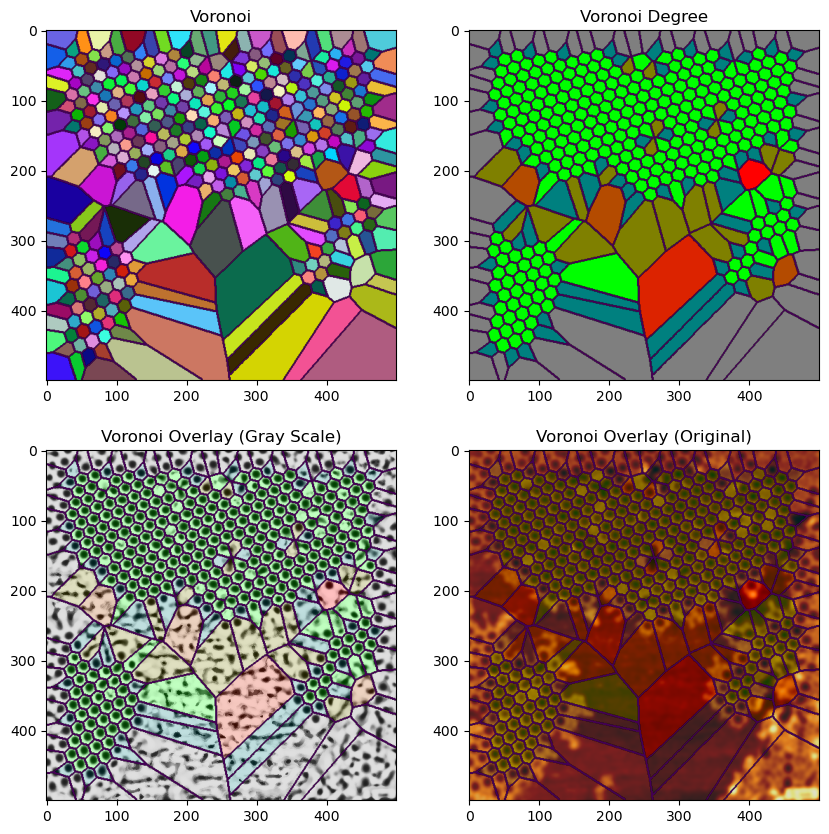

In [ ]:
fig, ax = plt.subplots(2,2,figsize=(10,10))
ax[0,0].imshow(img_vor_t)
ax[0,0].imshow(v_border)
ax[0,0].set_title('Voronoi')

ax[0,1].imshow(img_vor_deg_t)
ax[0,1].imshow(v_border)
ax[0,1].set_title('Voronoi Degree')

ax[1,0].imshow(img_gr, cmap='gray')
ax[1,0].imshow(img_vor_deg_t, alpha=0.25)
ax[1,0].imshow(v_border)
ax[1,0].set_title('Voronoi Overlay (Gray Scale)')

ax[1,1].imshow(colored_image)
ax[1,1].imshow(img_vor_deg_t, alpha=0.25)
ax[1,1].imshow(v_border)
ax[1,1].set_title('Voronoi Overlay (Original)')


### Plot the Graph over the Voronoi Diagram

NetworkX plotting is used to plot and overlay the Graphs on the data and Voronoi images.

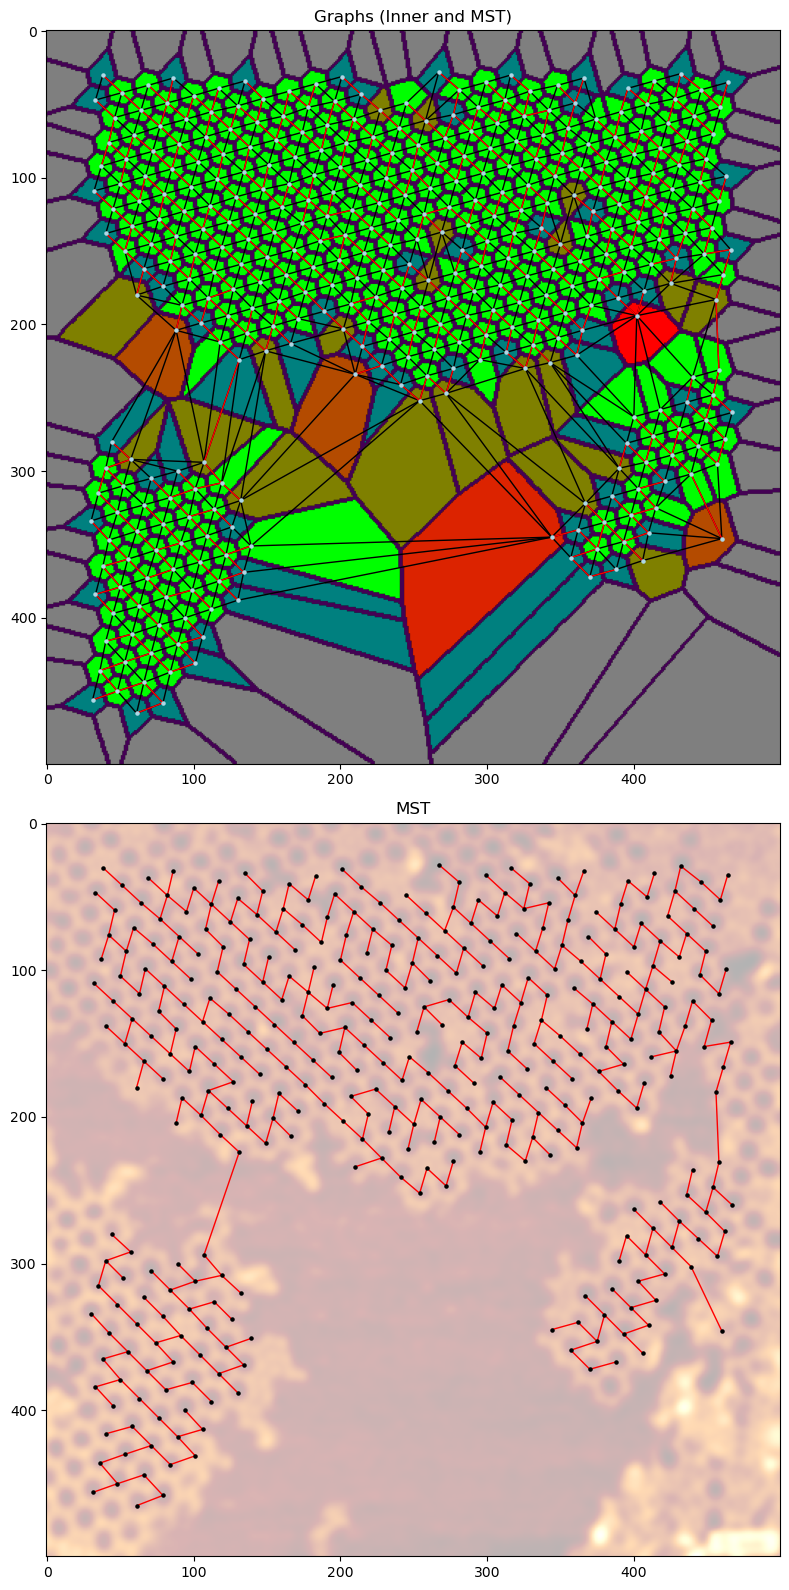

--- IMAGE INOFRMATION ---
IMAGE SIZE:    53.0 nm
PIXELS (X):    500 px
PIXELS (Y):    500 px
IMAGE AREA:    2809.0 nm^2
IMAGE SCALE:   9.433962264150944 px/nm
# OF NODES:    Graph with 375 nodes and 1045 edges
FILE NAME:     sample_scale_53.png

       --- STATISTICS ---
FILE NAME:          sample_scale_53.png
MEAN EDGE LENGTH:   0.836279 (normalized)
STANDARD DEVIATION: 0.172936 (normalized)
MEAN EDGE LENGTH:   2.255751 nm
STANDARD DEVIATION: 1.713502 nm
DEFECT RATIO:       0.232000
THE VALUE OF DSIZE: 10.640336
(0.836279, 0.172936)


In [ ]:
pos = {n:d['pixel_pos'] for n, d in graph_inner.nodes(data = True)}
pos_inner = {node:[dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in graph_inner.nodes(data = True)}
pos_msf = {node:[dat['pixel_pos'][1], dat['pixel_pos'][0]] for node, dat in g_msf.nodes(data = True)}

fig, ax = plt.subplots(1, 2, figsize = (16, 32))

ax[0].imshow(img_vor_deg_t)
ax[0].imshow(v_border)
ax[0].set_title('Graph (Inner and MST)')

xlim = ax[0].get_xlim()
ylim = ax[0].get_ylim()

nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'lightblue', node_size = 5, ax = ax[0], hide_ticks = False)
nx.draw_networkx_edges(graph_inner, pos_inner, edge_color = 'black', ax = ax[0], hide_ticks = False)

nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[0], hide_ticks = False)

ax[0].set_xlim(xlim)
ax[0].set_ylim(ylim)

ax[1].imshow(colored_image, alpha = 0.3)
ax[1].set_title('MST')
nx.draw_networkx_nodes(graph_inner, pos_inner, node_color = 'black', node_size = 5, ax = ax[1], hide_ticks = False)
nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax[1], hide_ticks = False)

ax[1].set_xlim(xlim)
ax[1].set_ylim(ylim)

plt.tight_layout()
plt.show()

# THIS IS THE INFORMATION WE GET FROM THE FILENAME
print("--- IMAGE INOFRMATION ---")
print(f"IMAGE SIZE:    {img.nm_size} nm")
print(f"PIXELS (X):    {img.px_sizex} px")
print(f"PIXELS (Y):    {img.px_sizey} px")
print(f"IMAGE AREA:    {img.area} nm^2")
print(f"IMAGE SCALE:   {img.scale} px/nm")
print(f"# OF NODES:    {graph_inner}") 
print(f"FILE NAME:     {img.name}")
print("=================================================")
print('')


_, _, m, sig, _,  defect_ratio = statistics(graph_node, graph_inner, g_msf)
_, _, _, _, G, _, _ = voronoi_tree(img, graph_node, k = k, power = power)
lengths = np.array([G[u][v]['dis'] for u, v in G.edges()])
m_1 = np.mean(lengths)
sig_1 = np.std(lengths)
dsize = (img.scale * m_1 / 2)

print('       --- STATISTICS ---')
print(f"FILE NAME:          {img.name}")
print(f'MEAN EDGE LENGTH:   {m:.6f} (normalized)')
print(f'STANDARD DEVIATION: {sig:.6f} (normalized)')
print(f'MEAN EDGE LENGTH:   {m_1:.6f} nm')
print(f'STANDARD DEVIATION: {sig_1:.6f} nm')
print(f'DEFECT RATIO:       {defect_ratio:.6f}')
print(f'THE VALUE OF DSIZE: {dsize:.6f}')
print("=================================================")

print(f"({m:.6f}, {sig:.6f})")

In [ ]:
# WE CAN TOGGLE THE POWER SWEEP ON/OFF
def run_power_sweep():
    global power
    original_power = power
    powers = np.round(np.arange(0.0, 1.1, 0.1), 1)

    m_values = []
    sig_values = []
    defect_ratio_values = []

    print(f"{'--- POWER SWEEP ---':>42}")
    print(f"{'POWER':>5} {'MEAN EDGE LENGTH':>22} {'STANDARD DEVIATION':>22} {'DEFECT RATIO':>17}")

    for power in powers:
        G = find_nodes(label_mask, Nlabel, px_a_th, img.scale)
        img_vor_t, img_vor_deg_t, v_border, G, G_inner, p_out, k_out = voronoi_tree(img, G, k=k, power=power)
        g_msf = nx.minimum_spanning_tree(G_inner, weight='dis')
        deg_list, deg_avg, m, sig, S, defect_ratio = statistics(G, G_inner, g_msf)

        m_values.append(m)
        sig_values.append(sig)
        defect_ratio_values.append(defect_ratio)

        print(f"{power:>4.1f} {m:>18.6f} {sig:>22.6f} {defect_ratio:21.6f}")

    power = original_power
    return powers, m_values, sig_values, defect_ratio_values

power_sweep = False
if power_sweep:
    powers, m_values, sig_values, defect_ratio_values = run_power_sweep()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(powers, m_values, 'o-', color='red', linewidth=2, markersize=8)
    axes[0].set_xlabel('POWER', fontsize=12)
    axes[0].set_ylabel('MEAN EDGE LENGTH', fontsize=12)
    axes[0].set_title('MEAN EDGE LENGTH VS. POWER', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(powers, sig_values, 's-', color='green', linewidth=2, markersize=8)
    axes[1].set_xlabel('POWER', fontsize=12)
    axes[1].set_ylabel('STANDARD DEVIATION', fontsize=12)
    axes[1].set_title('STANDARD DEVIATION VS. POWER', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(powers, defect_ratio_values, '^-', color='blue', linewidth=2, markersize=8)
    axes[2].set_xlabel('POWER', fontsize=12)
    axes[2].set_ylabel('DEFECT RATIO', fontsize=12)
    axes[2].set_title('DEFECT RATIO VS. POWER', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# K sweep: vary k from 4 to 24 in steps of 2
def run_k_sweep():
    global k
    original_k = k
    ks = np.arange(4, 25, 2)

    m_values = []
    sig_values = []
    defect_ratio_values = []
    all_deg_lists = []

    print(f"{'--- K SWEEP ---':>42}")
    print(f"{'K':>5} {'MEAN EDGE LENGTH':>22} {'STANDARD DEVIATION':>22} {'DEFECT RATIO':>17}")

    for k in ks:
        G = find_nodes(label_mask, Nlabel, px_a_th, img.scale)
        img_vor_t, img_vor_deg_t, v_border, G, G_inner, p_out, k_out = voronoi_tree(img, G, k=k, power=power)
        g_msf = nx.minimum_spanning_tree(G_inner, weight='dis')
        deg_list, deg_avg, m, sig, S, defect_ratio = statistics(G, G_inner, g_msf)

        m_values.append(m)
        sig_values.append(sig)
        defect_ratio_values.append(defect_ratio)
        all_deg_lists.append(deg_list)

        print(f"{k:>4.1f} {m:>18.6f} {sig:>22.6f} {defect_ratio:21.6f}")

    k = original_k
    return ks, m_values, sig_values, defect_ratio_values, all_deg_lists

k_sweep = False
if k_sweep:
    ks, m_values, sig_values, defect_ratio_values, all_deg_lists = run_k_sweep()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(ks, m_values, 'o-', color='red', linewidth=2, markersize=8)
    axes[0].set_xlabel('K', fontsize=12)
    axes[0].set_ylabel('MEAN EDGE LENGTH', fontsize=12)
    axes[0].set_title('MEAN EDGE LENGTH VS. K', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ks, sig_values, 's-', color='green', linewidth=2, markersize=8)
    axes[1].set_xlabel('K', fontsize=12)
    axes[1].set_ylabel('STANDARD DEVIATION', fontsize=12)
    axes[1].set_title('STANDARD DEVIATION VS. K', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ks, defect_ratio_values, '^-', color='blue', linewidth=2, markersize=8)
    axes[2].set_xlabel('K', fontsize=12)
    axes[2].set_ylabel('DEFECT RATIO', fontsize=12)
    axes[2].set_title('DEFECT RATIO VS. K', fontsize=12)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
def hex_lattice(img, spacing = 30, noise = 0, rng = None):
    if rng is None: 
        rng = np.random.default_rng(None)

    psx = img.px_sizex
    psy = img.px_sizey
    scale = img.scale

    a1 = np.array([1, 0]) * spacing
    a2 = np.array([0.5, np.sqrt(3) / 2]) * spacing 

    n_max = int(max(psx, psy) / spacing) + 2

    points = []
    for i in range(-n_max, n_max):
        for j in range(-n_max, n_max):
            pt = i * a1 + j * a2
            row, col = pt[1], pt[0]
            if 0 < row < psy and 0 < col < psx:
                points.append([row, col])
    
    points = np.array(points, dtype = np.float32)

    if noise > 0:
        points += rng.normal(0, noise, size = points.shape)
        points[:, 0] = np.clip(points[:, 0], 0, psy - 1)
        points[:, 1] = np.clip(points[:, 1], 0, psx - 1)

    G = nx.Graph()
    nominal_area = (spacing ** 2) * np.sqrt(3) / 2
    for idx, pos in enumerate(points, start = 1):
        G.add_node(idx, pixel_pos = pos, area = nominal_area / scale **2)
    return G, points

def square_lattice(img, spacing = 30, noise = 0, rng = None):
    if rng is None:
        rng = np.random.default_rng(None)

    psx = img.px_sizex
    psy = img.px_sizex
    scale = img.scale

    a1 = np.array([1, 0]) * spacing
    a2 = np.array([0, 1]) * spacing

    n_max = int(max(psx, psy) / spacing) + 2

    points = []
    for i in range(-n_max, n_max):
        for j in range(-n_max, n_max):
            pt = i * a1 + j * a2
            row, col = pt[1], pt[0]
            if 0 < row < psy and 0 < col < psx:
                points.append([row, col])

    points = np.array(points, dtype = np.float32)

    if noise > 0:
        points += rng.normal(0, noise, size = points.shape)
        points[:, 0] = np.clip(points[:, 0], 0, psy - 1)
        points[:, 1] = np.clip(points[:, 1], 0, psx - 1)

    G = nx.Graph()
    nominal_area = (spacing ** 2)
    for idx, pos in enumerate(points, start = 1):
        G.add_node(idx, pixel_pos = pos, area = nominal_area / scale ** 2)
    return G, points

def run_hex_validation(img, spacing = 30, noise = 0, k = 8, power = 0, rng = None):
    G, points = hex_lattice(img, spacing = spacing, noise = noise, rng = rng)

    _, _, _, G, G_inner, _, _ = voronoi_tree(img, G, k = k, power = power)
    g_msf = nx.minimum_spanning_tree(G_inner, weight ='dis')

    deg_list, deg_avg, m, sig, S, defect_ratio = statistics(G, G_inner, g_msf)
    return m, sig, defect_ratio, S, points

def run_square_validation(img, spacing = 30, noise = 0, k = 8, power = 0, rng = None):
    G, points = square_lattice(img, spacing = spacing, noise = noise, rng = rng)

    _, _, _, G, G_inner, _, _ = voronoi_tree(img, G, k = k, power = power)
    g_msf = nx.minimum_spanning_tree(G_inner, weight = 'dis' )

    deg_list, deg_avg, m, sig, S, defect_ratio = statistics(G, G_inner, g_msf)
    return m, sig, defect_ratio, S, points

lattice_test = False
if lattice_test:
    rng = np.random.default_rng(None)
    spacing = 10

    m0, sig0, dr0, S, points = run_hex_validation(img, spacing =spacing, noise = 0, k = 8)
    
    print('--- PERFECT HEXAGONAL LATTICE ---')
    print(f'MEAN EDGE LENGTH:     {m0:.6f} (normalized)')
    print(f'STANDARD DEVIATION:   {sig0:.2e} (normalized)')
    print(f'DEFECT RATIO:         {dr0:.6f}')

    m1, sig1, dr1, S1, points1 = run_square_validation(img, spacing = spacing, noise = 0, k = 8)

    print('--- PERFECT SQUARE LATTICE ---')
    print(f'MEAN EDGE LENGTH:     {m1:.6f} (normalized)')
    print(f'STANDARD DEVIATION:   {sig1:.2e} (normalized)')
    print(f'DEFECT RATIO:         {dr1:.6f}')

    noise_levels = np.linspace(0, spacing, 3)

    m_hex_list, sig_hex_list, dr_hex_list = [], [], []
    m_square_list, sig_square_list, dr_square_list = [], [], []

    for ns in noise_levels:
        m, sig, dr, S, points = run_hex_validation(img, spacing = spacing, noise = ns, k = 8, rng = rng)
        m_hex_list.append(m)
        sig_hex_list.append(sig)
        dr_hex_list.append(dr)

    for nss in noise_levels:
        m, sig, dr, S, points = run_square_validation(img, spacing = spacing, noise = nss, k = 8, rng = rng)
        m_square_list.append(m)
        sig_square_list.append(sig)
        dr_square_list.append(dr)

    noise_norm = noise_levels / spacing 

    test_plots = False
    if test_plots:
        fig, axes = plt.subplots(3, 1, figsize = (8, 10), sharex = True)

        axes[0].plot(noise_norm, m_hex_list, 'o-', color = 'blue')
        axes[0].set_ylabel('MEAN EDGE LEGNTH')
        axes[0].set_title('EFFECT OF NOISE ON STATISTICS')
        axes[0].grid(True)

        axes[1].plot(noise_norm, sig_hex_list, 's-', color = 'red')
        axes[1].set_ylabel('STANDARD DEVIAITON')
        axes[1].grid(True)

        axes[2].plot(noise_norm, dr_hex_list, '^-', color = 'green')
        axes[2].set_ylabel('DEFECT RATIO')
        axes[2].set_xlabel('NOISE / LATTICE SPACING')
        axes[2].grid(True)

        plt.tight_layout()
        plt.plot()

    test_mvs = True
    if test_mvs:

        m_data = []
    
        fig, ax = plt.subplots()

        ax.plot(m_hex_list, sig_hex_list)
        ax.plot(m_square_list, sig_square_list)
        ax.set_ylim(0, 0.4)
        ax.set_xlim(0.6, 1.1)

        m_data = [0.769170, 1.075, 1.018055, 0.9663, 1.005265, 0.943527, 1.022396, 1.017114, 0.662]
        sig_data = [0.201947, 0, 0.049074, 0.075531, 0.035693, 0.08701, 0.034246, 0.049273, 0.311]
        plt.scatter(m_data, sig_data)

        plt.tight_layout()
        plt.plot()


24.207991909980773 0.654962706565857
23.553029203414916


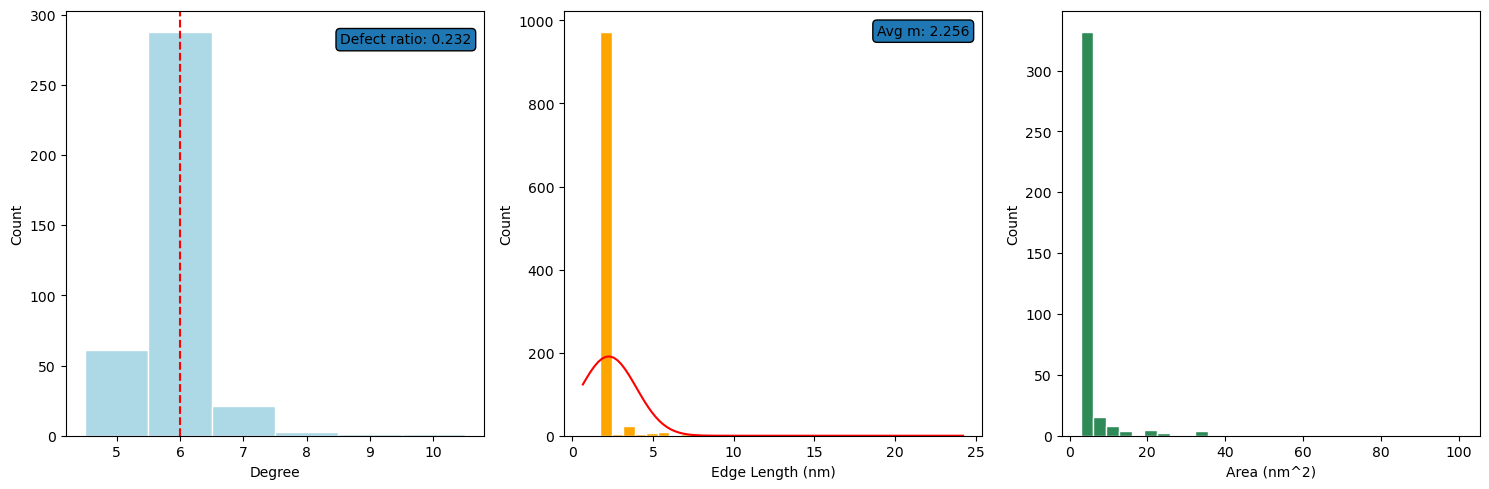

1045


In [ ]:
deg_list, _, m, sig, _, defect_ratio = statistics(graph_node, graph_inner, g_msf)

lenghts = np.array([G[u][v]['dis'] for u, v in G.edges()])
areas = [graph_inner.nodes[n]['area_vor'] for n in graph_inner.nodes()]

fig, axes = plt.subplots(1, 3, figsize = (15, 5))

#  DEGREE 
bins_deg = np.arange(min(deg_list) - 0.5, max(deg_list) + 1.5)
axes[0].hist(deg_list, bins = bins_deg, color = 'lightblue', edgecolor = 'white')
axes[0].axvline(6, color = 'red', linestyle = '--')
axes[0].annotate(f'Defect ratio: {defect_ratio:.3f}', xy = (0.97, 0.95), xycoords = 'axes fraction', ha = 'right', va = 'top', bbox = dict(boxstyle = 'round, pad = 0.3'))
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Count')

#   EDGE LEGNTHS
mean, std = norm.fit(lengths)
axes[1].hist(lengths, bins = 30, color = 'orange', edgecolor = 'white')
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
y = norm.pdf(x, mean, std) * len(lengths) * ((xmax - xmin) / 30)
plt.sca(axes[1])
plt.plot(x, y, 'red')
axes[1].annotate(f'Avg m: {lengths.mean():.3f}', xy = (0.97, 0.97), xycoords = 'axes fraction', ha = 'right', va = 'top', bbox = dict(boxstyle = 'round, pad = 0.3'))
axes[1].set_xlabel('Edge Length (nm)')
axes[1].set_ylabel('Count')
print(xmax, xmin)
print(xmax - xmin)

#   AREA
axes[2].hist(areas, bins = 30, color = 'seagreen', edgecolor = 'white')
axes[2].set_xlabel('Area (nm^2)')
axes[2].set_ylabel('Count')

fig.tight_layout()
plt.show()

print(len(lengths))



The nearest neighbor is located at r = 1.87267 (nm)


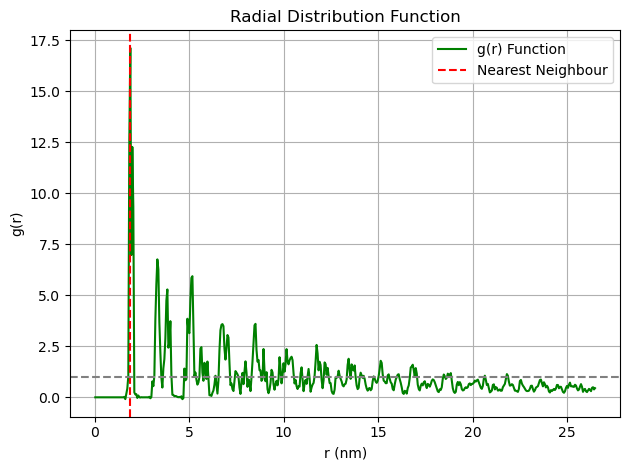

In [ ]:
node_positions = np.array([data['pixel_pos'] for node, data in graph_inner.nodes(data = True)])
node_positions = node_positions / img.scale
distances = pdist(node_positions)

psx = img.px_sizex / img.scale
psy = img.px_sizey / img.scale
a = psx * psy

no_nodes = len(node_positions)
r_max = 0.5 * max(psx, psy)
bins = len(node_positions)
edges = np.arange(0, r_max + r_max / bins, r_max / bins)
bin_width = edges[1] - edges[0]

counts, edges = np.histogram(distances, bins = edges)
r = 0.5 * (edges[:-1] + edges[1:])

def g_ideal(r):
    return 2 * np.pi * bin_width * (no_nodes / a) * r
g = (2 * counts) / (no_nodes * g_ideal(r))

r_g_spline = make_interp_spline(r, g)
r_ = np.linspace(r.min(), r.max(), 500)
g_ = r_g_spline(r_)

rmax = r[np.argmax(g)]
gmax = g.max()
print(f'The nearest neighbor is located at r = {rmax:.5f} (nm)')

plt.plot(r_, g_, color = 'green', ls = '-')
plt.axvline(rmax, color = 'red', ls = '--')
plt.axhline(1, color = 'gray', ls = '--')
plt.xlabel('r (nm)')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function')
plt.legend(['g(r) Function', 'Nearest Neighbour'])
plt.grid(True)

plt.tight_layout()
plt.show()



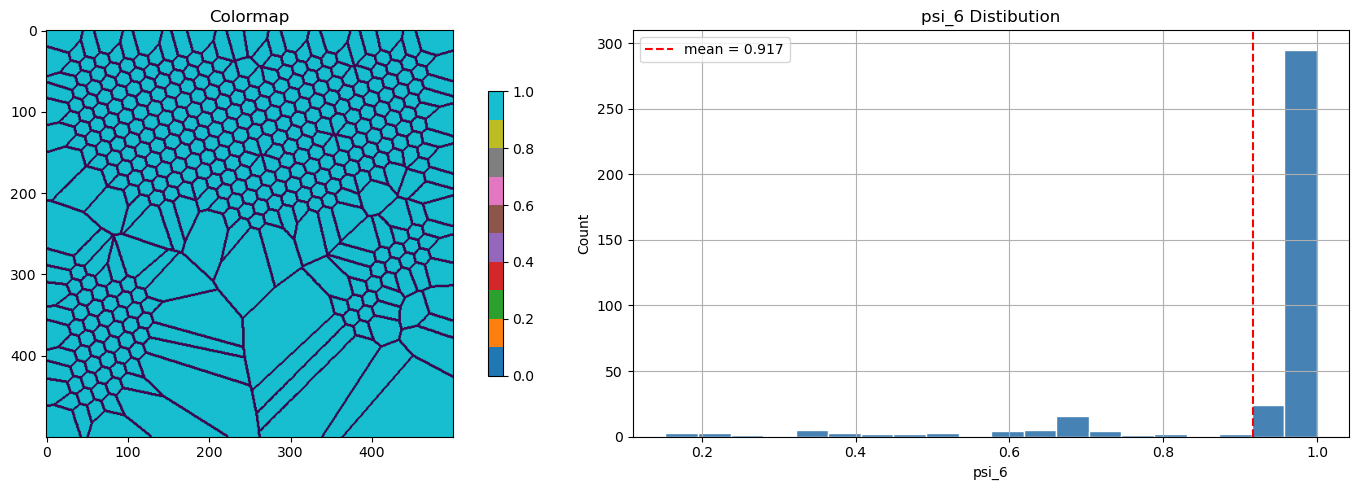

In [ ]:
for n in graph_inner.nodes():
    neighbors = list(graph_inner.neighbors(n))
    if len(neighbors) == 0:
        graph_inner.nodes[n]['psi6'] = 0.0
        continue

    p0 = graph_inner.nodes[n]['pixel_pos']
    theta = []
    for neighbor in neighbors:
        p1 = graph_inner.nodes[neighbor]['pixel_pos']
        dy = p1[0] - p0[0]
        dx = p1[1] - p0[1]
        theta.append(np.arctan2(dy, dx))
    
    theta = np.array(theta)
    psi6 = np.mean(np.exp(6j * theta))
    graph_inner.nodes[n]['psi6'] = np.abs(psi6)

psi6_values = np.array([graph_inner.nodes[n]['psi6'] for n in graph_inner.nodes()])
mean_psi6 = psi6_values.mean()

psi6_map = np.full(label_mask.shape, np.nan, dtype = float)
for n in graph_inner.nodes():
    psi6_map[label_mask == n] = graph_inner.nodes[n]['psi6']

fig, axes = plt.subplots(1, 2, figsize = (15, 5))

im = axes[0].imshow(psi6_map, cmap = 'tab10', vmin = 0, vmax = 1)
axes[0].imshow(v_border)
axes[0].set_title('Colormap')
fig.colorbar(im, ax = axes[0], shrink = 0.7)

axes[1].hist(psi6_values, bins = 20, color = 'steelblue', edgecolor = 'white')
axes[1].axvline(mean_psi6, color = 'red', ls = '--', label = f'mean = {mean_psi6:.3f}')
axes[1].set_xlabel('psi_6')
axes[1].set_ylabel('Count')
axes[1].set_title('psi_6 Distibution')
axes[1].legend()

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_voronoi(img, img_vor, img_vor_deg, v_border, G_inner, g_msf = None, 
                 show_borders = True, show_degree = False, show_random = False, 
                 show_gray_overlay = False, show_original_overlay = False, 
                 show_inner_graph = False, show_mst = False, 
                 img_gr = None, original_alpha = None, 
                 ax = None, title = None, save_path = None):
    if ax is None:
        fig, ax = plt.subplots(figsize = (8, 8))
    else:
        fig = ax.figure

    if original_alpha is not None:
        ax.imshow(img.img, alpha = original_alpha)
    elif show_gray_overlay:
        ax.imshow(img_gr, cmap = 'gray')
        ax.imshow(img_vor_deg, alpha = 0.25)
    elif show_original_overlay:
        ax.imshow(img.img)
        ax.imshow(img_vor_deg, alpha = 0.25)
    elif show_degree:
        ax.imshow(img_vor_deg)
    else:
        ax.imshow(v_border)

    if show_inner_graph or show_mst:
        xlim, ylim = ax.get_xlim(), ax.get_ylim()

        pos_inner = {n: [d['pixel_pos'][1], d['pixel_pos'][0]] for n, d in G_inner.nodes(data = True)}

        if show_inner_graph:
            nx.draw_networkx_nodes(G_inner, pos_inner, node_color = 'lightblue', ax = ax, hide_ticks = False)
            nx.draw_networkx_nodes(G_inner, pos_inner, edge_color = 'black', ax = ax, hide_ticks = False)

        if show_mst:
            pos_msf = {n: [d['pixel_pos'][1], d['pixel_pos'][0]] for n, d in g_msf.nodes(data = True)}
            nx.draw_networkx_edges(g_msf, pos_msf, edge_color = 'red', ax = ax, hide_ticks = False)

        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    if title:
        ax.set_title(title)
    
    if save_path is not None:
        fig.savegig(save_path, bbox_inches = 'tight', dpi = 200)

    return ax